In [ ]:
# Celda 1: Importar Librerías y Módulos (con adiciones para paralelismo y gestión de memoria)

import os
import numpy as np
import rasterio
from datetime import datetime
from tqdm import tqdm
import time
import gc # <--- MEJORA: Importar el Recolector de Basura

# --- ADICIONES PARA PARALELIZACIÓN Y MONITOREO ---
import threading
import psutil
from joblib import Parallel, delayed
# ---------------------------------------------------

# Importar los módulos personalizados del paquete lcp
import lcp.data_loader as dl
import lcp.processing as proc
import lcp.pathfinder as pf
import lcp.utils as utils

print("Módulos cargados exitosamente.")

Módulos cargados exitosamente.


In [ ]:
# Celda 2: Definición de Funciones (Worker, Monitor y Warm-up)

def lcp_worker(args):
    """
    Función que ejecuta el cálculo jerárquico para UN par de puntos.
    --- VERSIÓN MODIFICADA PARA USAR NP.MEMMAP Y GC.COLLECT() ---
    """
    origin_id, origin_coords, dest_id, dest_coords, shared_data = args
    
    print(f"--- Calculando ruta: {origin_id} -> {dest_id} ---", flush=True)

    # --- [MEJORA 1: NP.MEMMAP] ---
    # Cargar el array de coste desde el archivo mapeado en memoria en modo solo lectura.
    # No se recibe el array completo, solo su ruta, forma y tipo.
    cost_data_high_res = np.memmap(
        shared_data['memmap_path'], 
        dtype=shared_data['raster_dtype'], 
        mode='r', 
        shape=shared_data['raster_shape']
    )
    # ---------------------------
    
    main_search_mask = shared_data['main_search_mask']
    src_transform = shared_data['src_transform']
    src_crs = shared_data['src_crs']
    src_nodata = shared_data['src_nodata']
    src_res = shared_data['src_res']
    DOWNSAMPLING_FACTORS = shared_data['DOWNSAMPLING_FACTORS']
    CORRIDOR_BUFFER_PIXELS = shared_data['CORRIDOR_BUFFER_PIXELS']
    HEURISTIC_WEIGHT = shared_data['HEURISTIC_WEIGHT']
    OUTPUT_DIR = shared_data['OUTPUT_DIR']

    try:
        start_pixel_hr = proc.world_to_pixel(src_transform, origin_coords[0], origin_coords[1])
        end_pixel_hr = proc.world_to_pixel(src_transform, dest_coords[0], dest_coords[1])

        # ... (Fase 1: Búsqueda en baja resolución - Sin cambios) ...
        path_found_lr, path_pixels_lr, successful_factor, trans_low = False, None, None, None
        print(f"[{origin_id} -> {dest_id}] -> FASE 1: Buscando en baja resolución...", flush=True)
        for factor in DOWNSAMPLING_FACTORS:
            cost_lr = cost_data_high_res[::factor, ::factor]
            trans_lr = src_transform * src_transform.scale(factor, factor)
            dx_lr, dy_lr = src_res[0] * factor, src_res[1] * factor
            mask_lr = main_search_mask[::factor, ::factor]
            start_lr = (start_pixel_hr[0] // factor, start_pixel_hr[1] // factor)
            end_lr = (end_pixel_hr[0] // factor, end_pixel_hr[1] // factor)
            
            found, came_from_lr = pf.a_star_search(cost_lr, src_nodata, start_lr, end_lr, dx_lr, abs(dy_lr), HEURISTIC_WEIGHT, mask_lr)
            if found:
                path_found_lr, successful_factor, trans_low = True, factor, trans_lr
                path_pixels_lr = pf.reconstruct_path(came_from_lr, start_lr, end_lr)
                break
        
        # ... (Fase 2: Búsqueda en alta resolución - Sin cambios lógicos) ...
        print(f"[{origin_id} -> {dest_id}] -> FASE 2: Buscando en alta resolución...", flush=True)
        path_found_hr, came_from_hr = False, None
        if path_found_lr and path_pixels_lr is not None:
            corridor_mask = proc.create_search_corridor(path_pixels_lr, cost_data_high_res.shape, successful_factor, CORRIDOR_BUFFER_PIXELS)
            final_search_mask = np.logical_and(corridor_mask, main_search_mask)
            path_found_hr, came_from_hr = pf.a_star_search(cost_data_high_res, src_nodata, start_pixel_hr, end_pixel_hr, src_res[0], abs(src_res[1]), HEURISTIC_WEIGHT, final_search_mask)
        if not path_found_hr:
            path_found_hr, came_from_hr = pf.a_star_search(cost_data_high_res, src_nodata, start_pixel_hr, end_pixel_hr, src_res[0], abs(src_res[1]), HEURISTIC_WEIGHT, main_search_mask)

        if path_found_hr:
            path_pixels_hr = pf.reconstruct_path(came_from_hr, start_pixel_hr, end_pixel_hr)
            if path_pixels_lr is not None:
                p1_path = os.path.join(OUTPUT_DIR, f"ruta_fase1_{origin_id}_a_{dest_id}.shp")
                utils.save_path_to_shapefile(path_pixels_lr, trans_low, src_crs, p1_path)
            final_path_shp = os.path.join(OUTPUT_DIR, f"ruta_final_{origin_id}_a_{dest_id}.shp")
            utils.save_path_to_shapefile(path_pixels_hr, src_transform, src_crs, final_path_shp)
            
            print(f"  [{origin_id} -> {dest_id}] ÉXITO FINAL. Ruta guardada.", flush=True)
            
            # --- [MEJORA 2: GC.COLLECT] ---
            # Liberar memoria explícitamente antes de terminar el worker
            del came_from_hr, path_pixels_hr, came_from_lr, path_pixels_lr
            gc.collect()
            # ---------------------------
            
            return ("Éxito", origin_id, dest_id)
        else:
            print(f"  [{origin_id} -> {dest_id}] ERROR CRÍTICO: No se pudo encontrar ninguna ruta.", flush=True)
            return ("Fallo", origin_id, dest_id)

    except Exception as e:
        print(f"  [{origin_id} -> {dest_id}] ERROR INESPERADO: {e}", flush=True)
        return ("Error", origin_id, dest_id, str(e))

def resource_monitor(stop_event, records_list, interval=1):
    # (Esta función no cambia)
    process = psutil.Process(os.getpid())
    while not stop_event.is_set():
        cpu = psutil.cpu_percent(interval=None)
        mem = sum(p.memory_info().rss for p in [process] + process.children(recursive=True)) / (1024 * 1024)
        records_list.append({'cpu': cpu, 'mem_mb': mem})
        time.sleep(interval)

# --- [MEJORA 3: NUMBA WARM-UP] ---
def warm_up_numba():
    """
    Pre-compila las funciones Numba con datos de prueba para evitar race conditions.
    """
    print("Calentando (pre-compilando) funciones de Numba...")
    # Datos ficticios
    dummy_cost = np.ones((3, 3), dtype=np.float32)
    dummy_mask = np.ones((3, 3), dtype=bool)
    start, end = (0, 0), (2, 2)
    
    # Llamar a las funciones para compilarlas
    found, came_from = pf.a_star_search(dummy_cost, -9999, start, end, 1.0, 1.0, 1.0, dummy_mask)
    if found:
        _ = pf.reconstruct_path(came_from, start, end)
    print("Calentamiento de Numba completado.")
# ------------------------------------

print("Funciones 'worker' (optimizada), 'monitor' y 'warm_up' definidas.")

Funciones 'worker' (con logging forzado) y 'monitor' para la ejecución paralela definidas.


In [ ]:
# Celda 3: Lógica Principal de Ejecución

# --- 1. PARÁMETROS CONFIGURABLES POR EL USUARIO ---
BASE_DIR = os.getcwd()
#DATA_DIR = os.path.join(BASE_DIR, 'data')
DATA_DIR = os.path.join(r"C:\Users\Victor\OneDrive - Universidad Católica de Chile\Taller de Titulacion\2025\Rafaela Alegría\LCP-Rafa")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
#OUTPUT_DIR = os.path.join(BASE_DIR, 'output', f'session_{timestamp}_AllToAll_Optimized')
OUTPUT_DIR = os.path.join(DATA_DIR, 'output', f'session_{timestamp}_AllToAll_Optimized')
#COST_RASTER_PATH = os.path.join(DATA_DIR, 'cost.tif')
COST_RASTER_PATH = os.path.join(DATA_DIR, 'Coste_CN_corregido2.tif')
#ALL_POINTS_SHAPEFILE = os.path.join(DATA_DIR, 'points.shp')
ALL_POINTS_SHAPEFILE = os.path.join(DATA_DIR, 'Sitios Vergel area estudio.gpkg')
#MASK_SHAPEFILE_PATH = os.path.join(DATA_DIR, 'area-mask.shp')
MASK_SHAPEFILE_PATH = os.path.join(DATA_DIR, 'poligono utm cortado')
ID_FIELD_NAME = 'id'
DOWNSAMPLING_FACTORS = [32, 20, 10]
CORRIDOR_BUFFER_PIXELS = 150
HEURISTIC_WEIGHT = 1.0
N_JOBS = -2

In [ ]:
# Celda 4: CELDA DE VISUALIZACIÓN DIAGNÓSTICA

import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

print("Iniciando visualización diagnóstica del ráster de coste...")

# --- Parámetros de la Visualización ---
RASTER_A_VISUALIZAR = os.path.join(DATA_DIR, 'cost.tif') # Asegúrate que la ruta es correcta
# ----------------------------------------

try:
    with rasterio.open(RASTER_A_VISUALIZAR) as src:
        cost_data = src.read(1)
        
        # Reemplazar valores <= 0 por un valor muy pequeño para poder usar LogNorm
        # ya que log(0) no está definido.
        min_positive_val = np.min(cost_data[cost_data > 0])
        cost_data_log = np.where(cost_data <= 0, min_positive_val, cost_data)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

        # 1. Visualización Lineal (la problemática)
        im1 = ax1.imshow(cost_data, cmap='viridis')
        ax1.set_title('Escala Lineal (Barreras Ocultas)', fontsize=16)
        ax1.set_xlabel("Píxel X"); ax1.set_ylabel("Píxel Y")
        fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

        # 2. Visualización Logarítmica (la reveladora)
        im2 = ax2.imshow(cost_data_log, cmap='viridis', norm=LogNorm())
        ax2.set_title('Escala Logarítmica (Barreras Visibles)', fontsize=16)
        ax2.set_xlabel("Píxel X"); ax2.set_ylabel("Píxel Y")
        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"Ocurrió un error durante la visualización: {e}")

In [ ]:

##Celda 5: Ejecución Principal del Análisis Paralelo (Optimizado)

os.makedirs(OUTPUT_DIR, exist_ok=True)
monitoring_records = []
# --- [MEJORA 1: NP.MEMMAP] ---
# Definir la ruta para el archivo de memoria compartida
memmap_path = os.path.join(OUTPUT_DIR, 'shared_cost_surface.mmap')
# ---------------------------

print(f"Configuración lista. Los resultados se guardarán en: {OUTPUT_DIR}")

try:
    all_points, points_crs = dl.load_points_as_dict(ALL_POINTS_SHAPEFILE, ID_FIELD_NAME)
    
    with dl.load_raster(COST_RASTER_PATH) as src:
        # --- [MEJORA 1: NP.MEMMAP] ---
        # Crear el archivo memmap y volcar los datos del ráster en él
        print(f"Creando archivo de memoria compartida en: {memmap_path}")
        raster_shape = src.shape
        raster_dtype = src.dtypes[0]
        
        # 'w+' crea el archivo para lectura/escritura
        cost_data_memmap = np.memmap(memmap_path, dtype=raster_dtype, mode='w+', shape=raster_shape)
        cost_data_memmap[:] = src.read(1)
        cost_data_memmap.flush() # Asegura que los datos se escriben en disco
        print("Archivo de memoria compartida creado exitosamente.")
        # Ya no cargamos el ráster completo en una variable de memoria principal
        # del cost_data_high_res
        # ---------------------------

        if MASK_SHAPEFILE_PATH and os.path.exists(MASK_SHAPEFILE_PATH):
            main_search_mask = proc.create_mask_from_vector(MASK_SHAPEFILE_PATH, src)
        else:
            main_search_mask = np.ones(raster_shape, dtype=bool)

        # Modificar 'shared_data': ya no contiene el array de coste, sino la info para abrirlo
        shared_data = {
            'main_search_mask': main_search_mask,
            'src_transform': src.transform, 'src_crs': src.crs,
            'src_nodata': src.nodata, 'src_res': src.res,
            'DOWNSAMPLING_FACTORS': DOWNSAMPLING_FACTORS, 'CORRIDOR_BUFFER_PIXELS': CORRIDOR_BUFFER_PIXELS,
            'HEURISTIC_WEIGHT': HEURISTIC_WEIGHT, 'OUTPUT_DIR': OUTPUT_DIR,
            # --- [MEJORA 1: NP.MEMMAP] ---
            'memmap_path': memmap_path,
            'raster_dtype': raster_dtype,
            'raster_shape': raster_shape
            # ---------------------------
        }

    sorted_points = sorted(all_points.items())
    tasks = []
    for i, (origin_id, origin_coords) in enumerate(sorted_points):
        for dest_id, dest_coords in sorted_points[i+1:]:
            # Pasamos 'shared_data' completo a cada tarea
            tasks.append((origin_id, origin_coords, dest_id, dest_coords, shared_data))
    
    print(f"\nSe han preparado {len(tasks)} pares únicos para procesar.")

    # --- [MEJORA 3: NUMBA WARM-UP] ---
    warm_up_numba()
    # ------------------------------------

    stop_event = threading.Event()
    monitor_thread = threading.Thread(target=resource_monitor, args=(stop_event, monitoring_records))
    
    start_time = time.time()
    monitor_thread.start()
    
    results = Parallel(n_jobs=N_JOBS)(delayed(lcp_worker)(task) for task in tqdm(tasks, desc="Progreso General"))
    
    stop_event.set()
    monitor_thread.join()
    total_duration = time.time() - start_time

    # ... (El reporte final no cambia) ...
    exitos = [r for r in results if r[0] == "Éxito"]
    fallos = [r for r in results if r[0] == "Fallo"]
    errores = [r for r in results if r[0] == "Error"]
    
    print("\n" + "="*50)
    print("--- RESUMEN DE EJECUCIÓN PARALELA (OPTIMIZADA) ---")
    print(f"Proceso completado en {total_duration:.2f} segundos.")
    # ... (resto del reporte)

except Exception as e:
    print(f"\nOcurrió un error fatal en la ejecución: {e}")
    import traceback
    traceback.print_exc()
finally:
    if 'stop_event' in locals() and not stop_event.is_set():
        stop_event.set()
        
    # --- [MEJORA 1: NP.MEMMAP] ---
    # Limpiar el archivo de memoria compartida al finalizar
    if os.path.exists(memmap_path):
        print(f"Limpiando archivo de memoria compartida: {memmap_path}")
        os.remove(memmap_path)
    # ---------------------------
        
    print("\n--- ANÁLISIS PARALELO 'TODOS CON TODOS' COMPLETADO ---")

Configuración lista. Los resultados se guardarán en: G:\LCP-parallel\output\session_20250918_223234_AllToAll
Cargando puntos desde: G:\LCP-parallel\data\points.shp
Se cargaron 14 puntos.
Cargando raster desde: G:\LCP-parallel\data\cost.tif
Raster cargado exitosamente.
Cargando superficie de costo y máscara a memoria...
Creando máscara booleana desde el polígono...
Máscara creada.

Se han preparado 91 pares únicos para procesar.


Progreso General: 100%|████████████████████████████████████████████████████████████████| 91/91 [01:01<00:00,  1.48it/s]



--- RESUMEN DE EJECUCIÓN PARALELA ---
Proceso completado en 79.82 segundos.
Rutas calculadas con éxito: 91 de 91

--- Reporte de Rendimiento ---
Uso promedio de CPU: 90.69%
Pico de uso de Memoria: 2974.57 MB

--- ANÁLISIS PARALELO 'TODOS CON TODOS' COMPLETADO ---


Iniciando la visualización de la red completa de rutas...


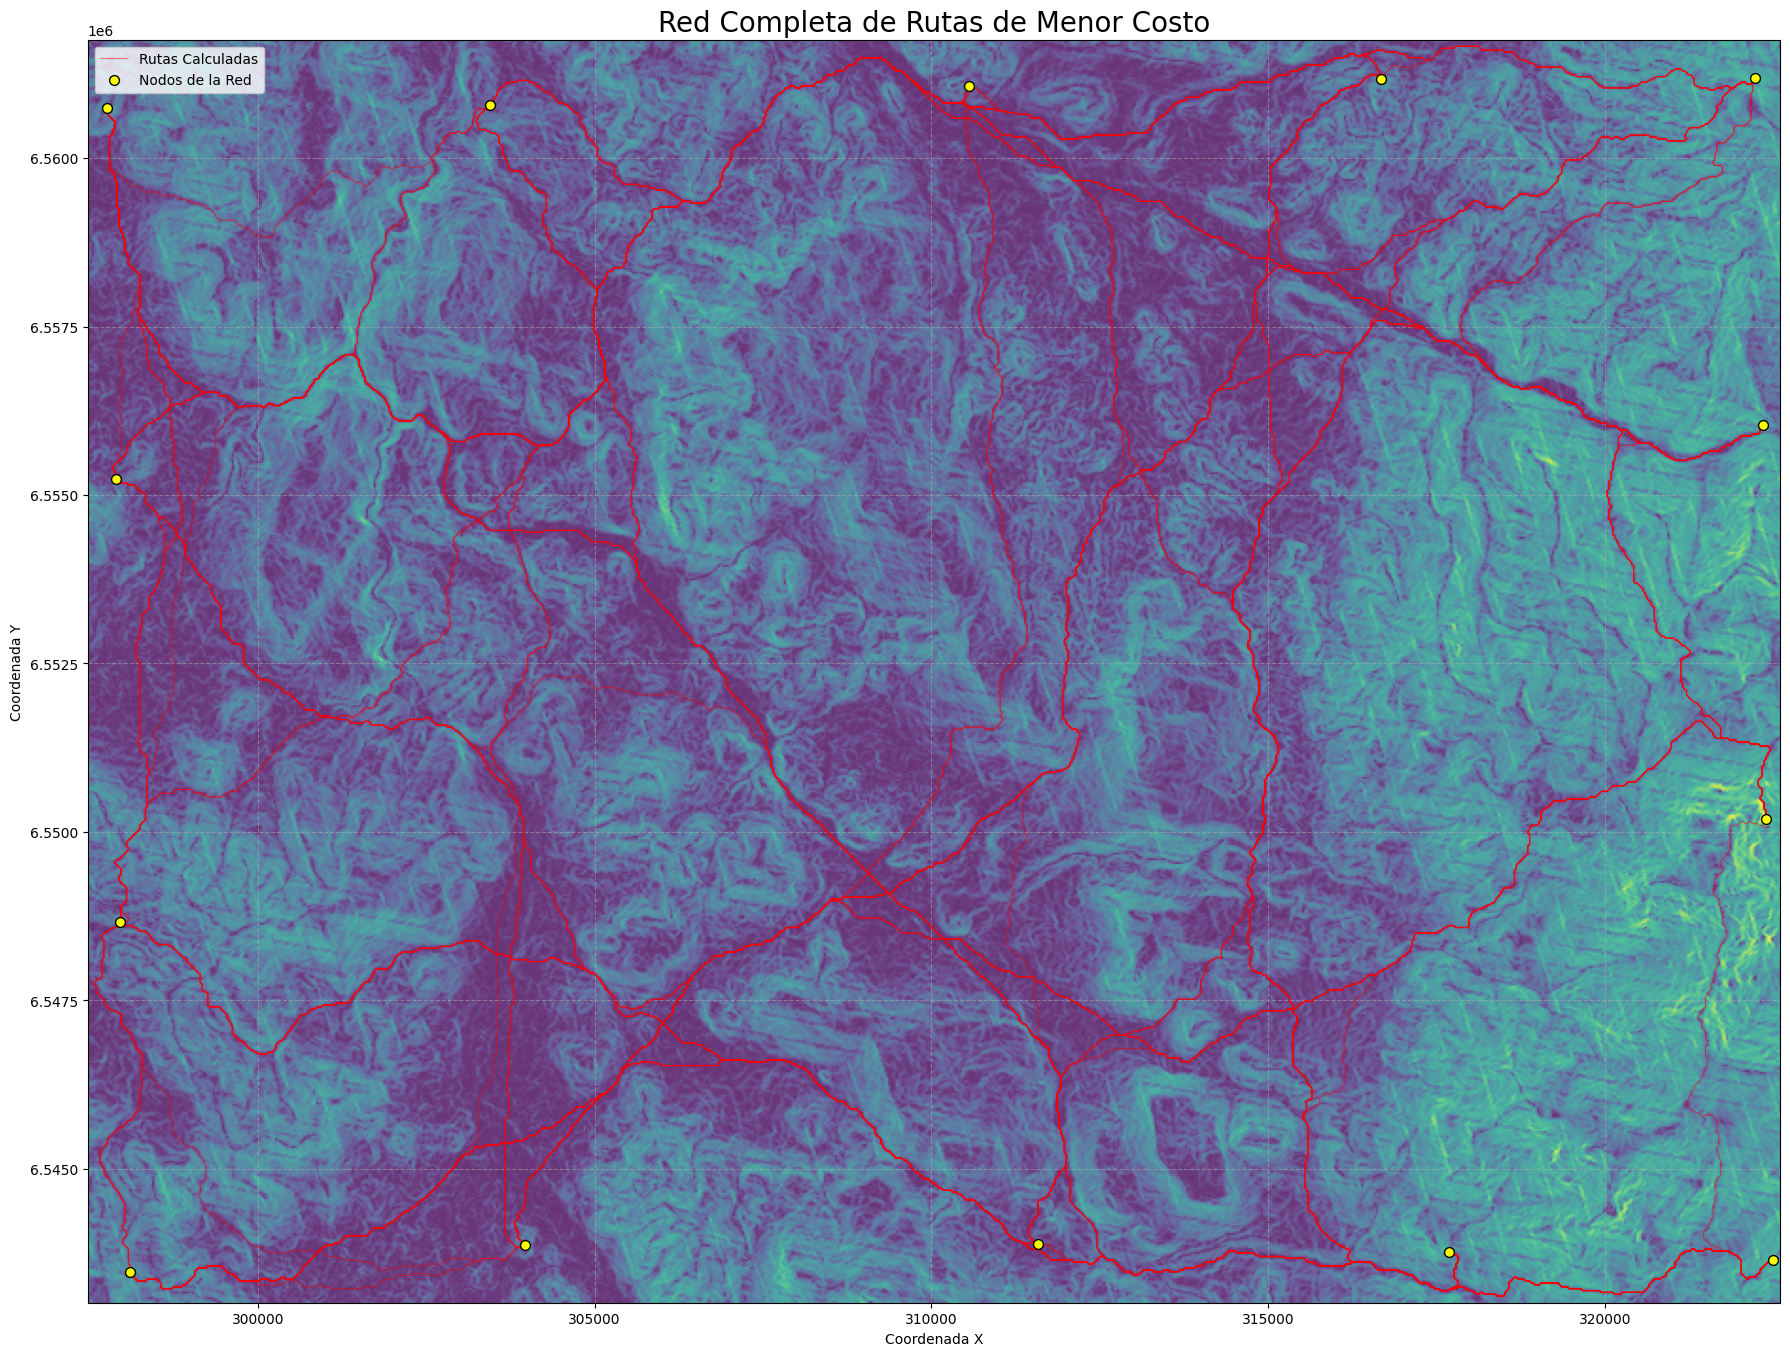

In [4]:
# ==============================================================================
# --- CELDA 4: VISUALIZACIÓN DE LA RED COMPLETA (TODOS CON TODOS) ---
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import geopandas as gpd
import pandas as pd
import rasterio
import rasterio.plot
from rasterio.windows import from_bounds
import glob

print("Iniciando la visualización de la red completa de rutas...")

try:
    # --- 1. Encontrar y cargar TODAS las rutas generadas ---
    # MODIFICACIÓN: El patrón glob ahora busca cualquier ruta final, sin especificar origen.
    final_route_files = glob.glob(os.path.join(OUTPUT_DIR, 'ruta_final_*.shp'))

    if not final_route_files:
        print("No se encontraron archivos de rutas finales para visualizar.")
    else:
        # Cargar todas las rutas en un único GeoDataFrame
        final_routes_gdf = pd.concat([gpd.read_file(f) for f in final_route_files], ignore_index=True)
        
        # --- 2. Determinar la extensión total con margen ---
        minx, miny, maxx, maxy = final_routes_gdf.total_bounds
        margin = 100
        buffered_bounds = (minx - margin, miny - margin, maxx + margin, maxy + margin)
        
        # --- 3. Cargar la porción del raster ---
        with rasterio.open(COST_RASTER_PATH) as src:
            window = from_bounds(*buffered_bounds, transform=src.transform)
            raster_data = src.read(1, window=window)
            window_transform = src.window_transform(window)

        # --- 4. Cargar todos los puntos ---
        points_gdf = gpd.read_file(ALL_POINTS_SHAPEFILE)

        # --- 5. Crear el mapa ---
        fig, ax = plt.subplots(figsize=(18, 18))
        rasterio.plot.show(raster_data, transform=window_transform, ax=ax, cmap='viridis', norm=LogNorm(), alpha=0.8)
        
        # MODIFICACIÓN: Dibujar todas las rutas con alta transparencia y líneas finas
        final_routes_gdf.plot(
            ax=ax,
            edgecolor='red',
            linewidth=0.8,  # Líneas más finas
            label='Rutas Calculadas',
            alpha=0.5,      # Alta transparencia para ver superposiciones
            zorder=3
        )
        
        # MODIFICACIÓN: Dibujar todos los puntos con el mismo estilo
        points_gdf.plot(
            ax=ax,
            color='yellow',
            markersize=50,
            ec='black',
            label='Nodos de la Red',
            zorder=5
        )

        # Configuración final del mapa
        ax.set_title('Red Completa de Rutas de Menor Costo', fontsize=20)
        ax.set_xlabel("Coordenada X"); ax.set_ylabel("Coordenada Y")
        ax.legend(); plt.grid(True, linestyle='--', alpha=0.5); plt.tight_layout(); plt.show()

except Exception as e:
    print(f"Ocurrió un error durante la visualización: {e}")
    import traceback
    traceback.print_exc()